# Decision Tree (Information Gain vs Gini Index)

Dataset used: Classic **Play Tennis Dataset**


In [1]:
import pandas as pd
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)


# Entropy formula:

Entropy(S) = - Σ p(x) log2 p(x)


In [2]:
def entropy(col):
    vals = col.value_counts(normalize=True)
    return -sum(p * math.log2(p) for p in vals)


# Information Gain

Information Gain = Entropy(parent) - Weighted Entropy(children)


In [3]:
def info_gain(df, attr):
    total_entropy = entropy(df['Play'])
    values = df[attr].unique()

    weighted_entropy = 0
    for v in values:
        subset = df[df[attr] == v]
        weighted_entropy += (len(subset)/len(df)) * entropy(subset['Play'])

    return total_entropy - weighted_entropy

In [4]:
print("Root Entropy:", entropy(df['Play']))
for col in df.columns[:-1]:
    print(f"Gain({col}) =", info_gain(df, col))

Root Entropy: 0.9402859586706311
Gain(Outlook) = 0.24674981977443933
Gain(Temperature) = 0.16195760493921973
Gain(Humidity) = 0.15183550136234159
Gain(Wind) = 0.04812703040826949


In [5]:
def build_tree_gain(df, depth=0):

    print("\n" + "   "*depth + "Node samples:", len(df))
    print("   "*depth + "Entropy:", round(entropy(df['Play']), 3))

    # Leaf node
    if len(df['Play'].unique()) == 1:
        print("   "*depth + "Leaf ->", df['Play'].iloc[0])
        return

    gains = {col: info_gain(df, col) for col in df.columns[:-1]}

    for k,v in gains.items():
        print("   "*depth + f"Gain({k}) =", round(v,3))

    best = max(gains, key=gains.get)
    print("   "*depth + "Best attribute:", best)

    for val in df[best].unique():
        print("   "*depth + f"Split {best} =", val)
        sub = df[df[best]==val].drop(columns=[best])
        build_tree_gain(sub, depth+1)

build_tree_gain(df)


Node samples: 14
Entropy: 0.94
Gain(Outlook) = 0.247
Gain(Temperature) = 0.162
Gain(Humidity) = 0.152
Gain(Wind) = 0.048
Best attribute: Outlook
Split Outlook = Sunny

   Node samples: 5
   Entropy: 0.971
   Gain(Temperature) = 0.971
   Gain(Humidity) = 0.971
   Gain(Wind) = 0.02
   Best attribute: Temperature
   Split Temperature = Hot

      Node samples: 2
      Entropy: -0.0
      Leaf -> No
   Split Temperature = Cool

      Node samples: 1
      Entropy: -0.0
      Leaf -> No
   Split Temperature = Mild

      Node samples: 2
      Entropy: -0.0
      Leaf -> Yes
Split Outlook = Overcast

   Node samples: 4
   Entropy: -0.0
   Leaf -> Yes
Split Outlook = Rain

   Node samples: 5
   Entropy: 0.971
   Gain(Temperature) = 0.02
   Gain(Humidity) = 0.02
   Gain(Wind) = 0.971
   Best attribute: Wind
   Split Wind = Weak

      Node samples: 3
      Entropy: -0.0
      Leaf -> Yes
   Split Wind = Strong

      Node samples: 2
      Entropy: -0.0
      Leaf -> No


# Now Using Gini Index

Gini formula:

Gini = 1 - Σ (p(x))²


In [6]:
def gini(col):
    vals = col.value_counts(normalize=True)
    return 1 - sum(p**2 for p in vals)

def gini_split(df, attr):
    values = df[attr].unique()

    weighted = 0
    for v in values:
        subset = df[df[attr]==v]
        weighted += (len(subset)/len(df)) * gini(subset['Play'])

    return weighted

In [7]:
print("Root Gini:", gini(df['Play']))
for col in df.columns[:-1]:
    print(f"Gini({col}) =", gini_split(df, col))

Root Gini: 0.4591836734693877
Gini(Outlook) = 0.34285714285714286
Gini(Temperature) = 0.36054421768707484
Gini(Humidity) = 0.3673469387755103
Gini(Wind) = 0.42857142857142855


In [8]:
def build_tree_gini(df, depth=0):

    print("\n" + "   "*depth + "Node samples:", len(df))
    print("   "*depth + "Gini:", round(gini(df['Play']), 3))

    if len(df['Play'].unique()) == 1:
        print("   "*depth + "Leaf ->", df['Play'].iloc[0])
        return

    ginis = {col: gini_split(df, col) for col in df.columns[:-1]}

    for k,v in ginis.items():
        print("   "*depth + f"Gini({k}) =", round(v,3))

    best = min(ginis, key=ginis.get)
    print("   "*depth + "Best attribute:", best)

    for val in df[best].unique():
        print("   "*depth + f"Split {best} =", val)
        sub = df[df[best]==val].drop(columns=[best])
        build_tree_gini(sub, depth+1)

build_tree_gini(df)


Node samples: 14
Gini: 0.459
Gini(Outlook) = 0.343
Gini(Temperature) = 0.361
Gini(Humidity) = 0.367
Gini(Wind) = 0.429
Best attribute: Outlook
Split Outlook = Sunny

   Node samples: 5
   Gini: 0.48
   Gini(Temperature) = 0.0
   Gini(Humidity) = 0.0
   Gini(Wind) = 0.467
   Best attribute: Temperature
   Split Temperature = Hot

      Node samples: 2
      Gini: 0.0
      Leaf -> No
   Split Temperature = Cool

      Node samples: 1
      Gini: 0.0
      Leaf -> No
   Split Temperature = Mild

      Node samples: 2
      Gini: 0.0
      Leaf -> Yes
Split Outlook = Overcast

   Node samples: 4
   Gini: 0.0
   Leaf -> Yes
Split Outlook = Rain

   Node samples: 5
   Gini: 0.48
   Gini(Temperature) = 0.467
   Gini(Humidity) = 0.467
   Gini(Wind) = 0.0
   Best attribute: Wind
   Split Wind = Weak

      Node samples: 3
      Gini: 0.0
      Leaf -> Yes
   Split Wind = Strong

      Node samples: 2
      Gini: 0.0
      Leaf -> No


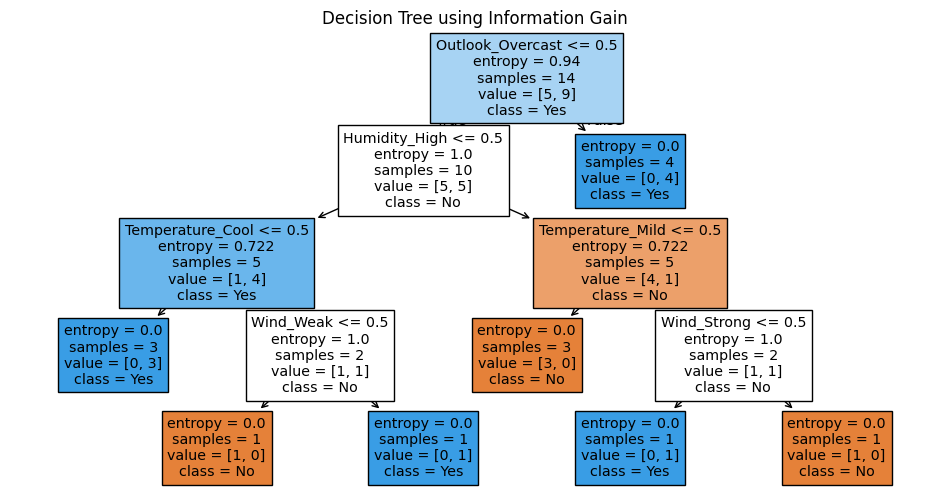

In [9]:
df_encoded = pd.get_dummies(df.drop(columns=['Play']))
y = df['Play']

model_entropy = DecisionTreeClassifier(criterion='entropy')
model_entropy.fit(df_encoded, y)

plt.figure(figsize=(12,6))
plot_tree(model_entropy,
          feature_names=df_encoded.columns,
          class_names=['No','Yes'],
          filled=True)
plt.title("Decision Tree using Information Gain")
plt.show()

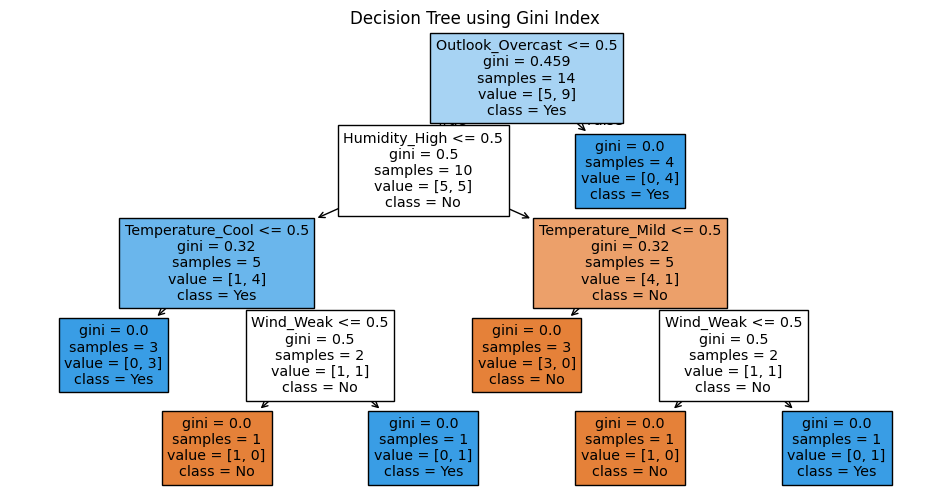

In [10]:
model_gini = DecisionTreeClassifier(criterion='gini')
model_gini.fit(df_encoded, y)

plt.figure(figsize=(12,6))
plot_tree(model_gini,
          feature_names=df_encoded.columns,
          class_names=['No','Yes'],
          filled=True)
plt.title("Decision Tree using Gini Index")
plt.show()